In [1]:
from satellite_RFI.src.satellite_sims import satellite_sim as ss
import time
import pickle
import astropy.units as u
from datetime import datetime
import tqdm
import os


import scipy as sp
import numpy as np
import pandas as pd
import scipy.optimize as opt
import matplotlib.pyplot as plt

In [3]:
obs_time_input=None#'2021 9 30 20 06 36'
# fname = '1554156377'
fname = '1551055211'


"""
Establishing the file name
"""
if obs_time_input!=None:
    obs_time_in=[int(x) for x in obs_time_input.split()]
    obs_time = datetime(obs_time_in[0], obs_time_in[1], obs_time_in[2], obs_time_in[3], obs_time_in[4], obs_time_in[5])
    dt = obs_time.strftime('%Y-%m-%d %H:%M:%S')
    fname = int((obs_time - datetime(1970, 1, 1)).total_seconds())
    print ("File name to be used is: "+str(fname))

else:
    print ("File name to be used is: "+str(fname))
    dt = (datetime.utcfromtimestamp(float(fname)).strftime('%Y-%m-%d %H:%M:%S'))
    print ("Date of observation date: "+str(dt))


##   
# Path to data
obs_data_path = '/idia/projects/hi_im/satellite_rfi/Observations/'
obs_results_path = '/idia/projects/hi_im/satellite_rfi/Results/'

katdal_info = pickle.load(open(obs_data_path+str(fname)+'/'+str(fname)+'_katdal_info.p', 'rb'), encoding='latin1')



info = [katdal_info[i] for i in katdal_info.keys()]

nd_s0=katdal_info['nd_s0']
nd_s0_coords=katdal_info['nd_s0_coords']
frequency=katdal_info['frequency']
fs=1000
fe=1500

results_data_save=obs_results_path+str(fname)+'/pickle_info/'
if os.path.exists(data_save)==False:
    os.mkdir(data_save)
    
data_mkat = '../../../Observation_results/Untangle/'+str(fname)+'/'
nearby_constellation_path = 'nearby_cons_time_idx.p'

folder1 = '2022_03_09'
folder2 = '2022_03_14'

File name to be used is: 1551055211
Date of observation date: 2019-02-25 00:40:11


### Full data

In [4]:
cons = ['GPS', 'SBAS', 'GAL', 'BDS', 'GLO', 'IRNSS']
bias = np.ones(len(cons))

sat_orig = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc=data_mkat,
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2.csv',
            plots_loc='data_test_plots/'+str(fname)+'/'+folder1+'/',
            sat_beam='emss_beam_r', frequency_range=[1000,1500], constellations=cons, nearby_satellites=nearby_constellation_path)

sat_shuffle = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc=data_mkat,
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2_shuffle.csv',
            plots_loc='data_test_plots/'+str(fname)+'/'+folder2+'/',
            sat_beam='emss_beam_r', frequency_range=[1000,1500], constellations=cons, nearby_satellites=nearby_constellation_path)



In [7]:
file = pickle.load(open('data_test/'+str(fname)+'/data_info/parallel_'+folder1+'/data_test_masked_full.p', 'rb'))
file_shuffle = pickle.load(open('data_test/'+str(fname)+'/data_info/parallel_'+folder2+'/data_test_shuffle_full.p', 'rb'))

In [12]:
file['best-fit']

array([1.17333332e+01, 2.75966816e+00, 1.25336088e+00, 7.48098061e-01,
       3.22094828e+00, 1.46064124e-01, 8.31288777e-01, 4.24939770e-01,
       4.17818378e+00, 9.56227857e-01, 5.70096632e-01, 2.32035471e-02,
       5.55365076e-07, 7.36227124e-02, 6.80389323e-01, 1.37554989e+00,
       8.12816109e+00, 5.55365076e-07, 1.82016762e+00, 1.54793999e+00,
       1.84483188e+00])

In [13]:
file_shuffle['best-fit']

array([5.55365076e-07, 1.54618281e+00, 7.48562611e-01, 5.70245392e-01,
       1.84448754e+00, 9.56235333e-01, 1.25333896e+00, 5.55365076e-07,
       2.75973021e+00, 8.01993759e-02, 1.17332390e+01, 3.22119663e+00,
       1.81932225e+00, 1.46031462e-01, 4.11807085e+00, 8.36605000e-01,
       1.37562323e+00, 4.26965050e-01, 2.28269784e-02, 8.11303098e+00,
       6.78657978e-01])

In [14]:
# Non-shuffled 
sat_orig.excecute(a_param=file['best-fit'], obs_time_start=file['time'][0], obs_time_end=file['time'][-1], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=bias, add_sub=[1, 1], band_lvl=[None, None], bandsize=None)

orig_sim_sat = np.ma.array(data=sat_orig.simulation_TOD_slice, mask=sat_orig.mask_nearby_satellites_slice.T).T
orig_data_sat = np.ma.array(data=sat_orig.calibration_data_slice, mask=sat_orig.mask_nearby_satellites_slice.T).T

orig_full = [orig_sim_sat, orig_data_sat]

# Shuffled 
sat_shuffle.excecute(a_param=file_shuffle['best-fit'], obs_time_start=file_shuffle['time'][0], obs_time_end=file_shuffle['time'][-1], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=bias, add_sub=[1, 1], band_lvl=[None, None], bandsize=None)

shuffle_sim_sat = np.ma.array(data=sat_shuffle.simulation_TOD_slice, mask=sat_shuffle.mask_nearby_satellites_slice.T).T
shuffle_data_sat = np.ma.array(data=sat_shuffle.calibration_data_slice, mask=sat_shuffle.mask_nearby_satellites_slice.T).T


shuffle_full = [shuffle_sim_sat, shuffle_data_sat]

extent = [sat_shuffle.frequency_band[sat_shuffle.frequency_idx[0]], sat_shuffle.frequency_band[sat_shuffle.frequency_idx[1]],\
            sat_shuffle.nd_s0[sat_shuffle.time_idx[1]], sat_shuffle.nd_s0[sat_shuffle.time_idx[0]]]


waterfall = [orig_sim_sat, orig_data_sat, shuffle_sim_sat, shuffle_data_sat]
waterfall_name = ['Original Simulation', 'Original Data', 'Shuffle Simulation', 'Shuffle Data']


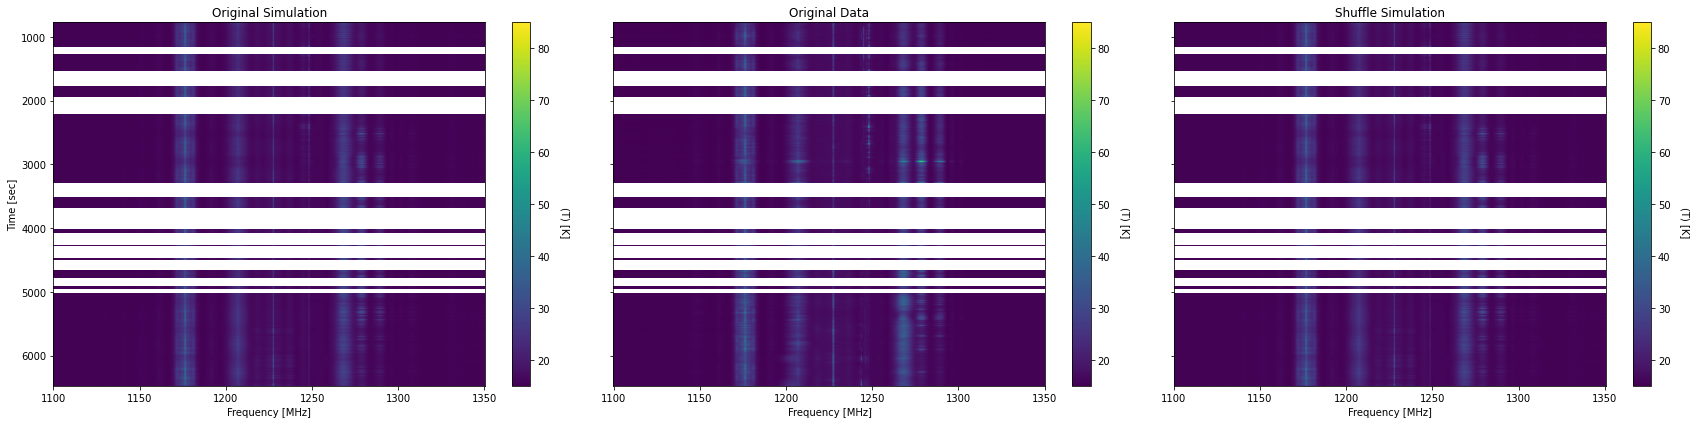

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(24,6), sharey=True)
fig.subplots_adjust()

for plot in range(3):
    ax=axs[plot]
    if plot<3:
        val_max, val_min = np.ma.max(orig_full), np.ma.min(orig_full)
    else:
        val_max, val_min = np.ma.max(shuffle_full), np.ma.min(shuffle_full)

    hb = ax.imshow(waterfall[plot], aspect='auto', extent=extent, vmax=val_max, vmin=val_min)
    ax.set_title(waterfall_name[plot])
    cbar = plt.colorbar(hb,ax=ax)
    cbar.set_label(r'(T) [K]', rotation=270, labelpad=20, y=0.45)

    if plot==0:
        ax.set_ylabel('Time [sec]')
    ax.set_xlabel('Frequency [MHz]')

    
plt.tight_layout()
# plt.savefig('data_test_plots/'+fname+'/'+folder+'/waterfall_'+num+'.pdf')
plt.show()

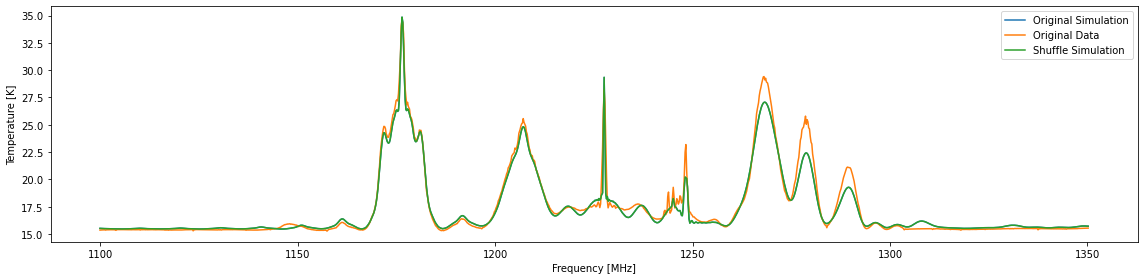

In [16]:
freqs = sat_shuffle.frequency_band[sat_shuffle.frequency_idx[0]:sat_shuffle.frequency_idx[1]]

fig, axs = plt.subplots(1, 1, figsize=(16,4), sharey=False)
fig.subplots_adjust()
for plot in range(3):
    ax=axs
 
    ax.plot(freqs, np.ma.mean(waterfall[plot], axis=0), label=waterfall_name[plot])

    ax.legend()  
    if plot<1:
        ax.set_ylabel('Temperature [K]')
    ax.set_xlabel('Frequency [MHz]')
plt.tight_layout()
# plt.savefig('data_test_plots/'+fname+'/'+folder+'/average_over_time_'+num+'.pdf')
plt.show()

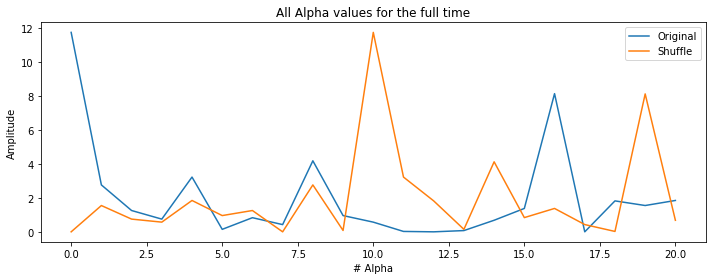

In [19]:
plt.figure(figsize=(10,4))
plt.plot(np.arange(len(file['best-fit'])), file['best-fit'], label='Original')
plt.plot(np.arange(len(file_shuffle['best-fit'])), file_shuffle['best-fit'], label='Shuffle')

plt.title('All Alpha values for the full time')

plt.xlabel('# Alpha')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.savefig('data_test_plots/1551055211/full_alpha.pdf')
plt.show()

In [22]:
file_shuffle['best-fit']

array([1.17305393e+01, 2.76005501e+00, 1.25501633e+00, 3.84233636e-01,
       3.22000598e+00, 1.46371272e-01, 9.03062696e-01, 4.26938837e-01,
       4.12388076e+00, 9.56225272e-01, 5.70252609e-01, 5.55349215e-07,
       5.55365076e-07, 1.58226137e+00, 6.84722886e-01, 1.37253322e+00,
       4.74931943e+00, 5.55365076e-07, 1.84375401e+00, 1.81979339e+00,
       2.88845880e+00])

In [24]:
file['best-fit']

array([1.17333332e+01, 2.75966816e+00, 1.25336088e+00, 7.48098061e-01,
       3.22094828e+00, 1.46064124e-01, 8.31288777e-01, 4.24939770e-01,
       4.17818378e+00, 9.56227857e-01, 5.70096632e-01, 2.32035471e-02,
       5.55365076e-07, 7.36227124e-02, 6.80389323e-01, 1.37554989e+00,
       8.12816109e+00, 5.55365076e-07, 1.82016762e+00, 1.54793999e+00,
       1.84483188e+00])

### Chunck data

In [32]:
cons = ['GPS', 'SBAS', 'GAL', 'BDS', 'GLO', 'IRNSS']
bias = np.ones(len(cons))

sat_orig = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc=data_mkat,
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2.csv',
            plots_loc='data_test_plots/'+str(fname)+'/'+folder1+'/',
            sat_beam='emss_beam_r', frequency_range=[1000,1500], constellations=cons, nearby_satellites=nearby_constellation_path)

sat_shuffle = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc=data_mkat,
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2_shuffle.csv',
            plots_loc='data_test_plots/'+str(fname)+'/'+folder2+'/',
            sat_beam='emss_beam_r', frequency_range=[1000,1500], constellations=cons, nearby_satellites=nearby_constellation_path)



In [42]:
# num = 'chunk_'+str(1)  # Glo-ops
# num = 'chunk_'+str(11)  # galileo
num = 'chunk_'+str(4)  # none

chunk_file_orig = pickle.load(open('data_test/'+str(fname)+'/data_info/parallel_'+folder1+'/data_test_masked_'+num+'.p', 'rb'))
chunk_file_shuffle = pickle.load(open('data_test/'+str(fname)+'/data_info/parallel_'+folder2+'/data_test_un_masked_'+num+'.p', 'rb'))

In [43]:
print ('Timestamp:\t'+str(np.round(chunk_file_orig['time'][0],2))+'\t\t'+str(np.round(chunk_file_orig['time'][-1],2)))

Timestamp:	1808.32		2068.21


In [44]:
# Masked 
sat_orig.excecute(a_param=chunk_file_orig['best-fit'], obs_time_start=chunk_file_orig['time'][0], obs_time_end=chunk_file_orig['time'][-1], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=bias, add_sub=[1, 1], band_lvl=[None, None], bandsize=None)

orig_sim_sat = np.ma.array(data=sat_orig.simulation_TOD_slice, mask=sat_orig.mask_nearby_satellites_slice.T).T
orig_data_sat = np.ma.array(data=sat_orig.calibration_data_slice, mask=sat_orig.mask_nearby_satellites_slice.T).T

orig = [orig_sim_sat, orig_data_sat]

# Unmasked 
sat_shuffle.excecute(a_param=chunk_file_shuffle['best-fit'], obs_time_start=chunk_file_shuffle['time'][0], obs_time_end=chunk_file_shuffle['time'][-1], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=bias, add_sub=[1, 1], band_lvl=[None, None], bandsize=None)

shuffle_sim_sat = np.ma.array(data=sat_shuffle.simulation_TOD_slice, mask=sat_shuffle.mask_nearby_satellites_slice.T).T
shuffle_data_sat = np.ma.array(data=sat_shuffle.calibration_data_slice, mask=sat_shuffle.mask_nearby_satellites_slice.T).T

shuffle = [shuffle_sim_sat, shuffle_data_sat]

extent = [sat_orig.frequency_band[sat_orig.frequency_idx[0]], sat_orig.frequency_band[sat_orig.frequency_idx[1]],\
            sat_orig.nd_s0[sat_orig.time_idx[1]], sat_orig.nd_s0[sat_orig.time_idx[0]]]


waterfall = [orig_sim_sat, orig_data_sat, shuffle_sim_sat, shuffle_data_sat]
waterfall_name = ['Original Simulation', 'Original Data', 'Shuffle Simulation', 'Shuffle Data']



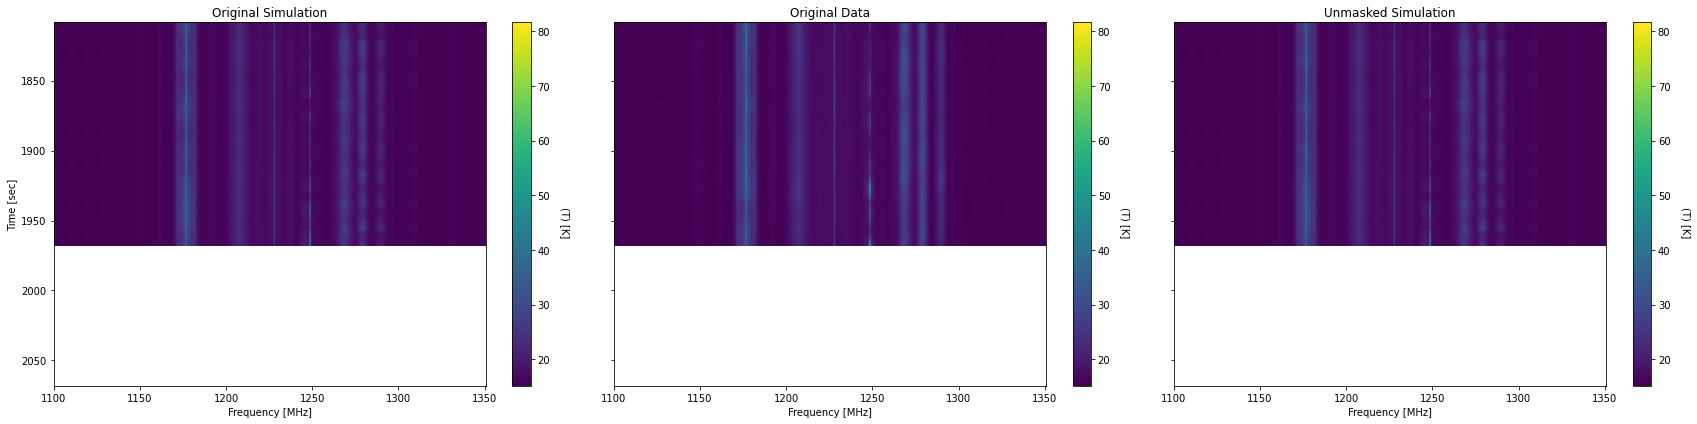

In [45]:
fig, axs = plt.subplots(1, 3, figsize=(24,6), sharey=True)
fig.subplots_adjust()

for plot in range(3):
    ax=axs[plot]
    if plot<3:
        val_max, val_min = np.ma.max(shuffle), np.ma.min(shuffle)
    else:
        val_max, val_min = np.ma.max(shuffle), np.ma.min(shuffle)

    hb = ax.imshow(waterfall[plot], aspect='auto', extent=extent, vmax=val_max, vmin=val_min)
    ax.set_title(waterfall_name[plot])
    cbar = plt.colorbar(hb,ax=ax)
    cbar.set_label(r'(T) [K]', rotation=270, labelpad=20, y=0.45)

    if plot==0:
        ax.set_ylabel('Time [sec]')
    ax.set_xlabel('Frequency [MHz]')

    
plt.tight_layout()
# plt.savefig('data_test_plots/'+fname+'/'+folder+'/waterfall_'+num+'.pdf')
plt.show()

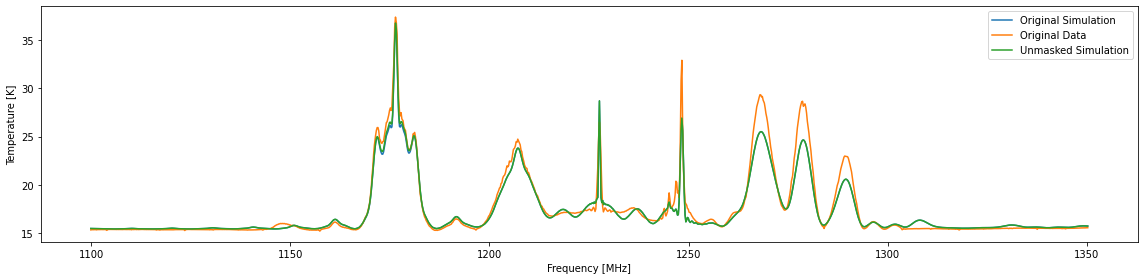

In [46]:
freqs = sat_shuffle.frequency_band[sat_shuffle.frequency_idx[0]:sat_shuffle.frequency_idx[1]]

fig, axs = plt.subplots(1, 1, figsize=(16,4), sharey=False)
fig.subplots_adjust()
for plot in range(3):
    ax=axs
 
    ax.plot(freqs, np.ma.mean(waterfall[plot], axis=0), label=waterfall_name[plot])

    ax.legend()  
    if plot<1:
        ax.set_ylabel('Temperature [K]')
    ax.set_xlabel('Frequency [MHz]')
plt.tight_layout()
# plt.savefig('data_test_plots/'+fname+'/'+folder+'/average_over_time_'+num+'.pdf')
plt.show()

In [48]:
# plt.figure(figsize=(10,4))


# plt.plot(freqs, np.ma.mean(waterfall[0]-waterfall[1], axis=0), label='Mask')
# plt.plot(freqs, np.ma.mean(waterfall[2]-waterfall[3], axis=0), label='Unmask', alpha=0.4)

# plt.title('Difference between the Simulation and Data')
# plt.xlabel('Frequency [MHz]')
# plt.ylabel('Temperature [K]')

# plt.legend()
# plt.tight_layout()
# # plt.savefig('data_test_plots/'+fname+'/'+folder+'/difference_sim_vs_data_'+num+'.pdf')
# plt.show()

### All chunk alpha data


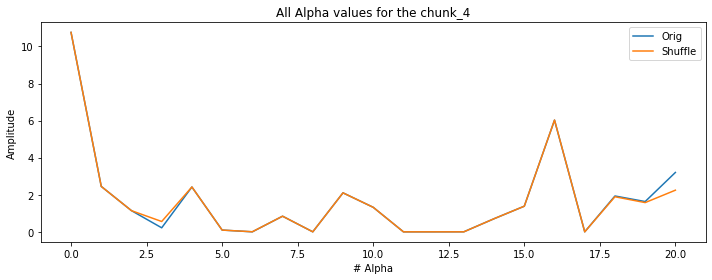

In [49]:
plt.figure(figsize=(10,4))
plt.plot(chunk_file_orig['best-fit'], label='Orig')
plt.plot(chunk_file_shuffle['best-fit'], label='Shuffle')

plt.title('All Alpha values for the '+num)

plt.xlabel('# Alpha')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
chunk_alpha = []

for c_i in range(22):

    num='chunk_'+str(c_i)
    chunk_file_m = pickle.load(open('data_test/'+str(fname)+'/data_info/parallel_'+folder+'/data_test_masked_'+num+'.p', 'rb'))
    chunk_file_um = pickle.load(open('data_test/'+str(fname)+'/data_info/parallel_'+folder+'/data_test_un_masked_'+num+'.p', 'rb'))

    chunk_alpha.append([chunk_file_m['best-fit'], chunk_file_um['best-fit']])

chunk_alpha = np.array(chunk_alpha)

In [12]:
chunk_alpha[3*7, 0, :]

array([1.09125344e+01, 3.22520538e+00, 1.13688256e+00, 4.84746381e-01,
       7.60546436e+00, 5.55365076e-07, 9.01395563e+00, 1.60470711e-02,
       6.67690029e+00, 9.27259819e-01, 4.56384206e-01, 5.55365076e-07,
       5.55365076e-07, 4.12863811e+00, 7.47134226e-01, 1.05371459e+00,
       1.51286615e+00, 5.55365076e-07, 1.69337117e+00, 1.43843175e+00,
       2.33742628e+00])

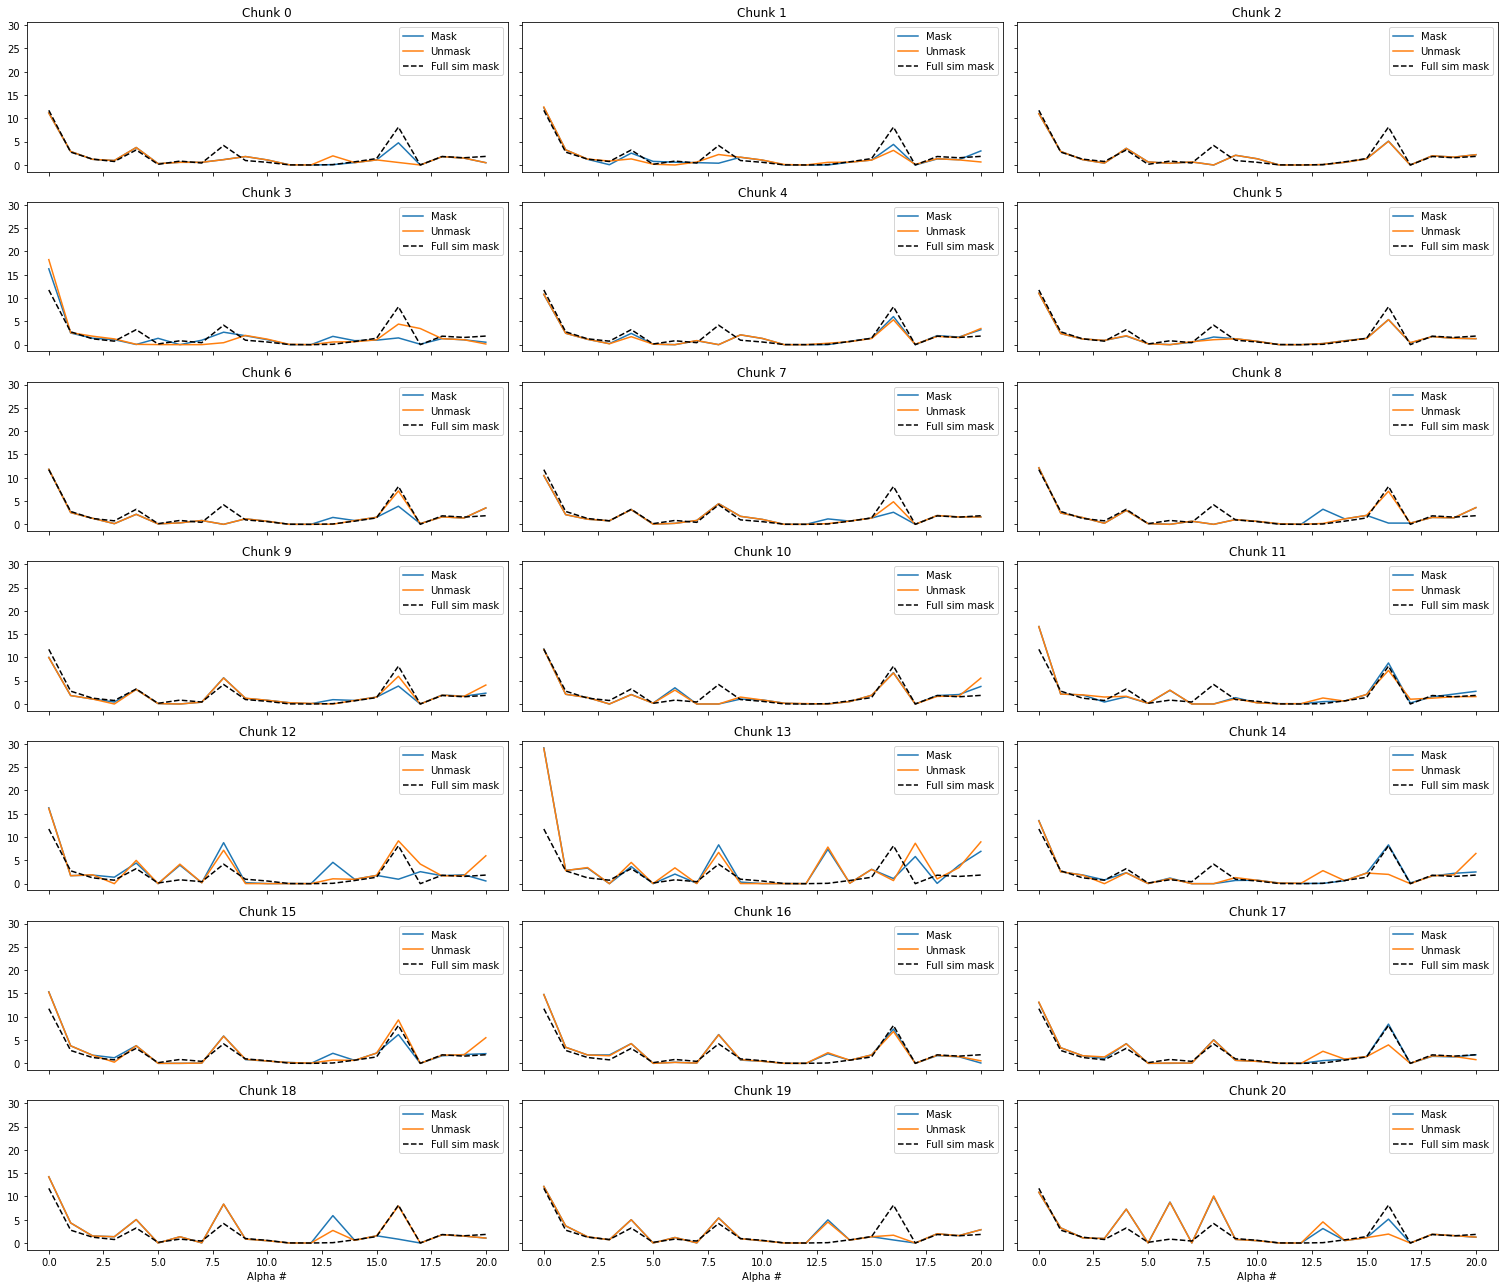

In [50]:
fig, axs = plt.subplots(7, 3, figsize=(21,18), sharex=True, sharey=True)
fig.subplots_adjust()

for r_plot in range(7):
    for c_plot in range(3):
        ax=axs[r_plot, c_plot]
        
        ax.plot(chunk_alpha[3*r_plot+c_plot, 0, :], label='Mask')
        ax.plot(chunk_alpha[3*r_plot+c_plot, 1, :], label='Unmask')
        ax.plot(file_m['best-fit'], 'k--', label='Full sim mask')
        
        ax.set_title('Chunk '+str(3*r_plot+c_plot))
        
        if 3*r_plot+c_plot > 17:
            ax.set_xlabel('Alpha #')
        ax.legend()
        
        
plt.tight_layout()
# plt.savefig('data_test_plots/'+fname+'/'+folder+'/all_chunks_.pdf')
plt.show()

### All alpha  values

In [14]:
alpha_val_total = []
for a_i in range(21):
    alpha_val = []

    for c_i in range(22):

        num='chunk_'+str(c_i)
        chunk_file_m = pickle.load(open('data_test/'+str(fname)+'/data_info/parallel_'+folder+'/data_test_masked_'+num+'.p', 'rb'))
        chunk_file_um = pickle.load(open('data_test/'+str(fname)+'/data_info/parallel_'+folder+'/data_test_un_masked_'+num+'.p', 'rb'))

        alpha_val.append([chunk_file_m['best-fit'][a_i], chunk_file_um['best-fit'][a_i]])


    alpha_val = np.array(alpha_val)
    alpha_val_total.append(alpha_val)
alpha_val_total=np.array(alpha_val_total)

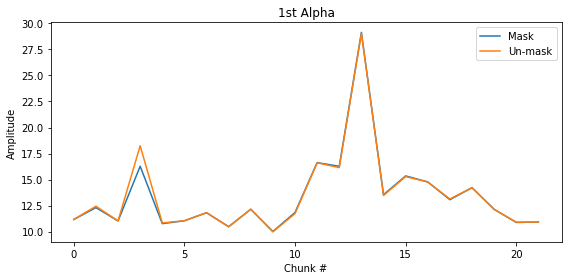

In [60]:
plt.figure(figsize=(8,4))
plt.plot(alpha_val_total[0,:,0], label='Mask')
plt.plot(alpha_val_total[0,:,1], label='Un-mask')

plt.title('1st Alpha')
plt.xlabel('Chunk #')
plt.ylabel('Amplitude')

plt.legend()
plt.tight_layout()
plt.savefig('data_test_plots/'+fname+'/'+folder+'/all_1st_alpha_.pdf')
plt.show()

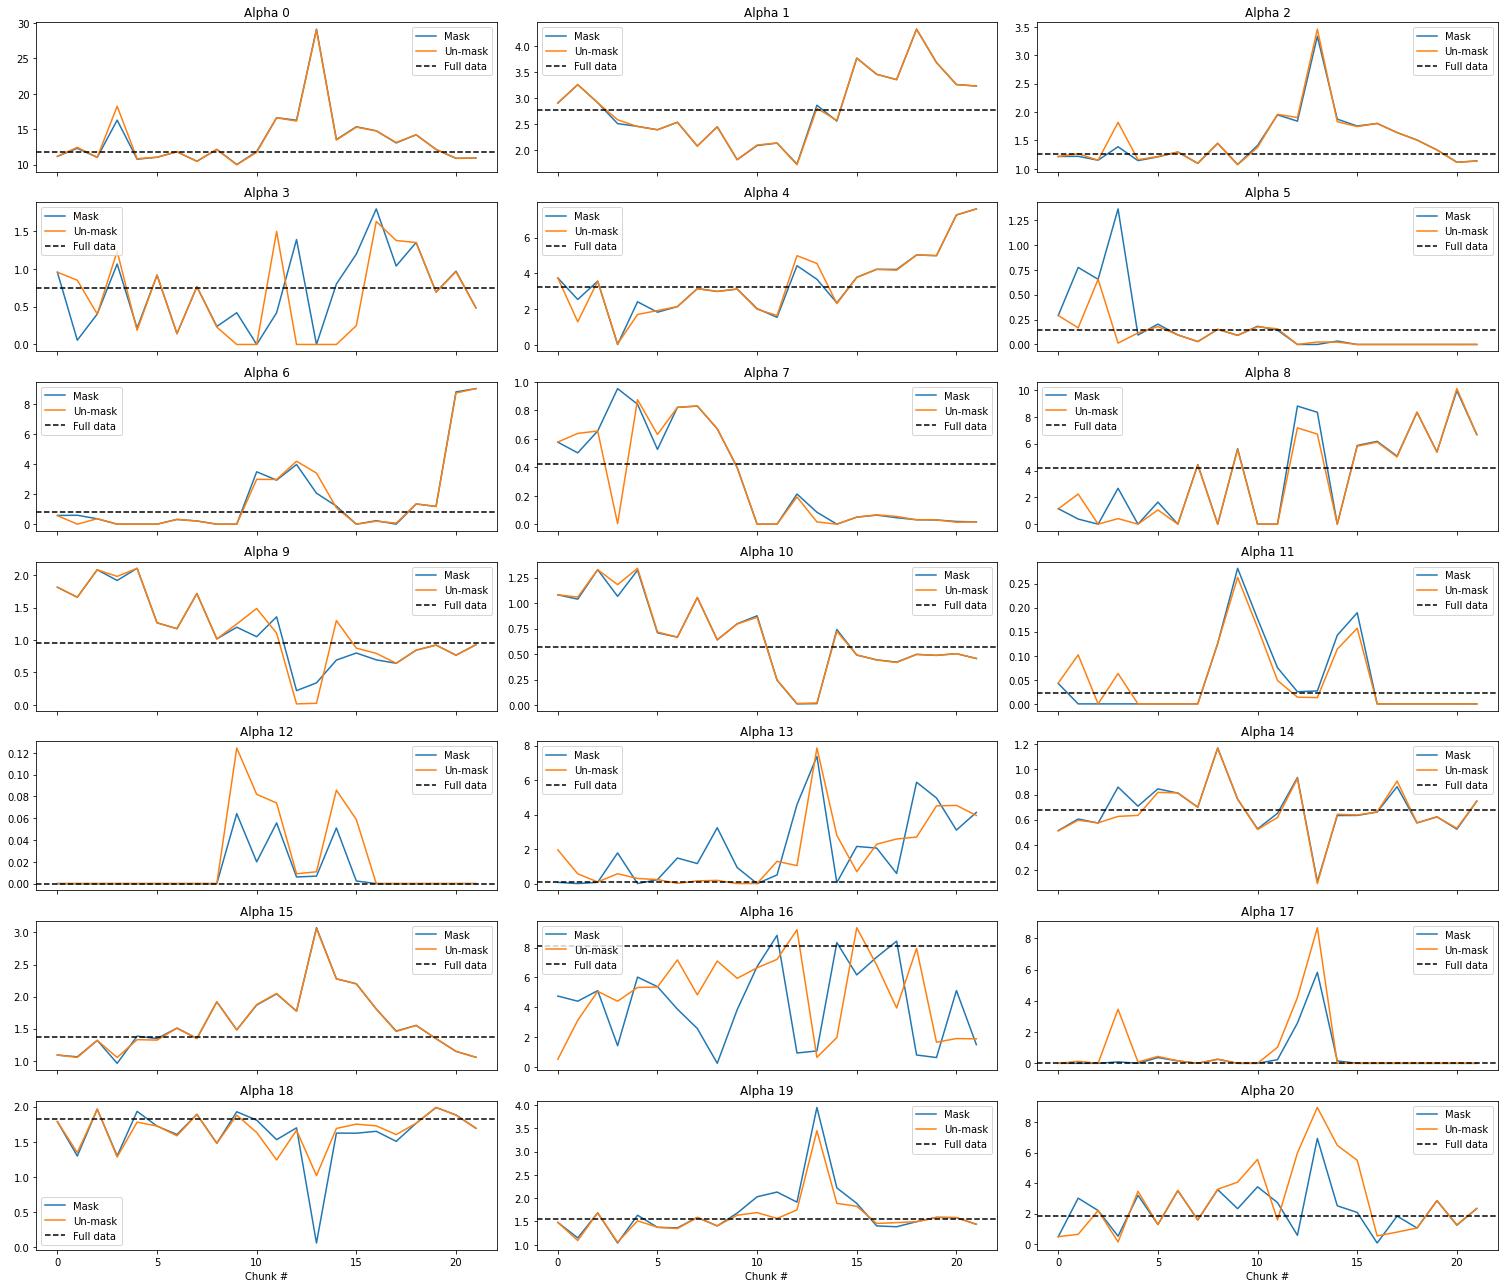

In [56]:
fig, axs = plt.subplots(7, 3, figsize=(21,18), sharex=True)
fig.subplots_adjust()

for r_plot in range(7):
    for c_plot in range(3):
        ax=axs[r_plot, c_plot]
        
        ax.set_title('Alpha '+str(3*r_plot+c_plot))
        ax.plot(alpha_val_total[3*r_plot+c_plot,:,0], label='Mask')
        ax.plot(alpha_val_total[3*r_plot+c_plot,:,1], label='Un-mask')
        ax.axhline(file_m['best-fit'][3*r_plot+c_plot], color='k', ls='--', label='Full data')
        
        if 3*r_plot+c_plot > 17:
            ax.set_xlabel('Chunk #')
        ax.legend()


plt.tight_layout()
# plt.savefig('data_test_plots/'+fname+'/'+folder+'/all_alpha.pdf')
plt.show()